# Credit Fraud Dataset

Conjunto de Datos de Detección de Fraude con Tarjetas de Crédito
Este conjunto de datos contiene 10,000 transacciones con tarjeta de crédito diseñadas para apoyar la investigación y experimentación en la detección de fraudes utilizando aprendizaje automático. Los datos simulan de manera realista tanto transacciones legítimas como fraudulentas, manteniendo una distribución de clases naturalmente desbalanceada, lo cual refleja los sistemas financieros del mundo real.

El conjunto de datos es adecuado para tareas de clasificación binaria, donde el objetivo es predecir si una transacción es fraudulenta (1) o legítima (0) en función del comportamiento de la transacción, indicadores de riesgo e información del titular de la tarjeta.

📊 **Características del Dataset**  
- **Total de registros:** 10,000  
- **Total de características:** 10  
- **Variable objetivo:** `is_fraud`  
- **Distribución de clases:** Muy desbalanceada (fraude ≈ 4–5%)  
- **Tipo de datos:** Sintético (seguro para privacidad)  

🧾 **Descripción de las características**  

| Nombre de la característica | Descripción |
|-----------------------------|-------------|
| transaction_id              | Identificador único de cada transacción |
| amount                      | Monto de la transacción |
| transaction_hour            | Hora de la transacción (0–23) |
| merchant_category           | Tipo de comerciante |
| foreign_transaction         | Indica si la transacción es internacional (0/1) |
| location_mismatch           | Desajuste entre ubicación de facturación y ubicación de la transacción (0/1) |
| device_trust_score          | Puntuación de confianza del dispositivo (0–100) |
| velocity_last_24h           | Número de transacciones en las últimas 24 horas |
| cardholder_age              | Edad del titular de la tarjeta |
| is_fraud                    | Variable objetivo (0 = Normal, 1 = Fraude) |


## importacion de datos

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None) #Para que se vean todas las columnas
fraud_data = pd.read_csv("credit_card_fraud.csv")
fraud_data.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


##### Revision de tipos, Faltantes y Columnas

In [3]:
#Tipos de dato de cada variable y cantidad de no-nulos por cada una
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


No tenemos faltantes de informacion!!

In [4]:
# Remuevo el transaction id ya que es algo que no me interesa

fraud_data = fraud_data.drop(columns='transaction_id')

Descriptivos por Atributo

In [5]:
# Para las numericas

fraud_data.select_dtypes(include='number').agg(['count', 'mean', 'std', 'min', 'max','median']) 

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
max,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000
median,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000


In [6]:
# Para las categoricas
fraud_data.select_dtypes(include='object').describe()

,merchant_category
count,10000
unique,5
top,Food
freq,2093


# Algunos graficos

### Histogramas para categoricas

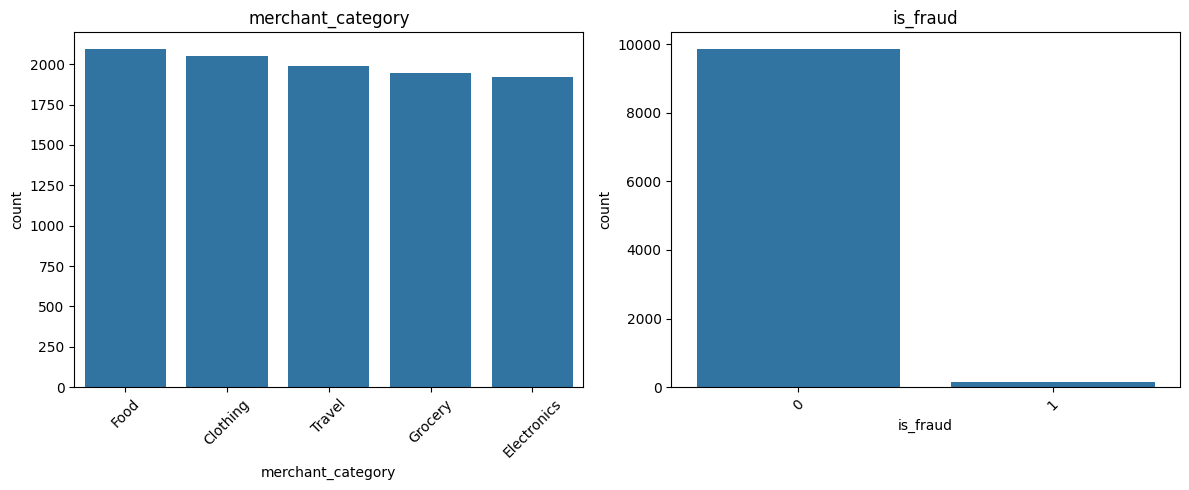

In [7]:

columns_to_plot = ['merchant_category', 'is_fraud']  

n_cols = 2  # columnas por fila
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols  # filas necesarias

plt.figure(figsize=(n_cols*6, n_rows*5))

for i, col in enumerate(columns_to_plot):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=fraud_data, x=col, order=fraud_data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

Se observa gran mayoria de casos de no fraude -> mucho desbalanceo

#### Cuantitativas

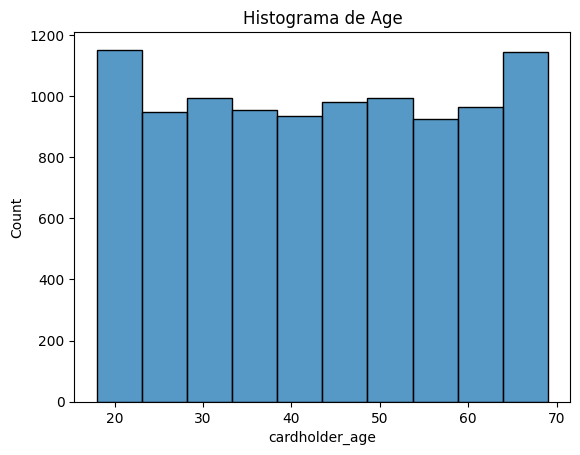

In [8]:
sns.histplot(data=fraud_data, x=fraud_data.cardholder_age, bins=10)     
plt.title("Histograma de Age")
plt.show()
# tiene una distribucion bastante uniforme

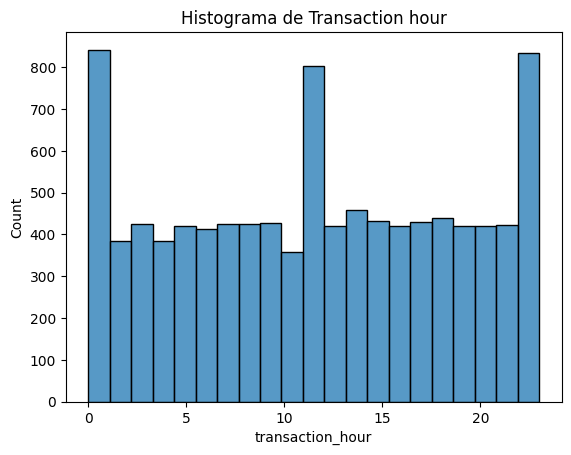

In [9]:
sns.histplot(data=fraud_data, x=fraud_data.transaction_hour)  
plt.title("Histograma de Transaction hour")
plt.show()
# hay algunos momentos en los que se realizan una mayor cantidad de transacciones

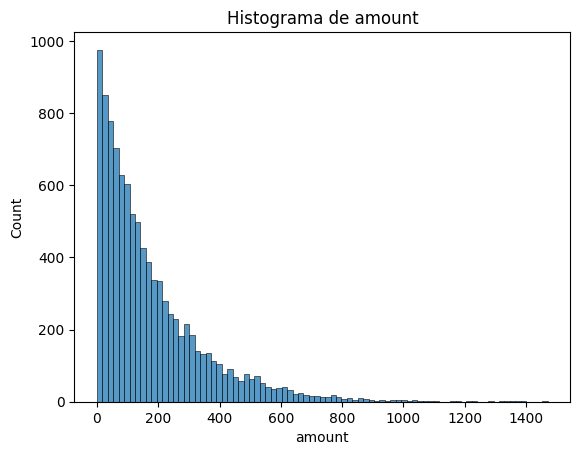

In [10]:
sns.histplot(data=fraud_data, x=fraud_data.amount)  
plt.title("Histograma de amount")
plt.show()
# distribucion gamma 

separo la variable target

In [11]:
y = fraud_data.is_fraud # 1 si es fraude 0 si no
X = fraud_data.drop(columns='is_fraud')

Identificar categoricas y numericas

Codifico la categorica en one-hot

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [13]:
cat_cols = X.select_dtypes(include='object').columns.tolist()  # categóricas
num_cols = X.select_dtypes(include='number').columns.tolist()  # numéricas

In [14]:
#Preprocesador para las Categoricas

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

# Aplico la transformacion
X_processed_array = preprocessor.fit_transform(X)

# Reasigno nombre a numericas

# Crear nombres de columnas
columns = list(preprocessor.get_feature_names_out())
# Renombrar numéricas para quitar 'remainder__'
columns = [col.replace('remainder__','') for col in columns]

# Convertir a DataFrame
X_processed = pd.DataFrame(X_processed_array, columns=columns, index=X.index)

print("Columnas procesadas:", X_processed.shape[1])


Columnas procesadas: 11


Divido en train/test

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=0, stratify=y
)

Armado del modelo

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=5,          # limitar profundidad para evitar sobreajuste
    class_weight={0:1, 1:20},  # darle más peso a la clase minoritaria para evitar hacer oversampling 
    random_state=0        # determinista
)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

Evaluacion

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import export_text


In [20]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1950   20]
 [   1   29]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.59      0.97      0.73        30

    accuracy                           0.99      2000
   macro avg       0.80      0.98      0.86      2000
weighted avg       0.99      0.99      0.99      2000



Evaluo la importancia de los features

In [21]:
from sklearn.tree import plot_tree

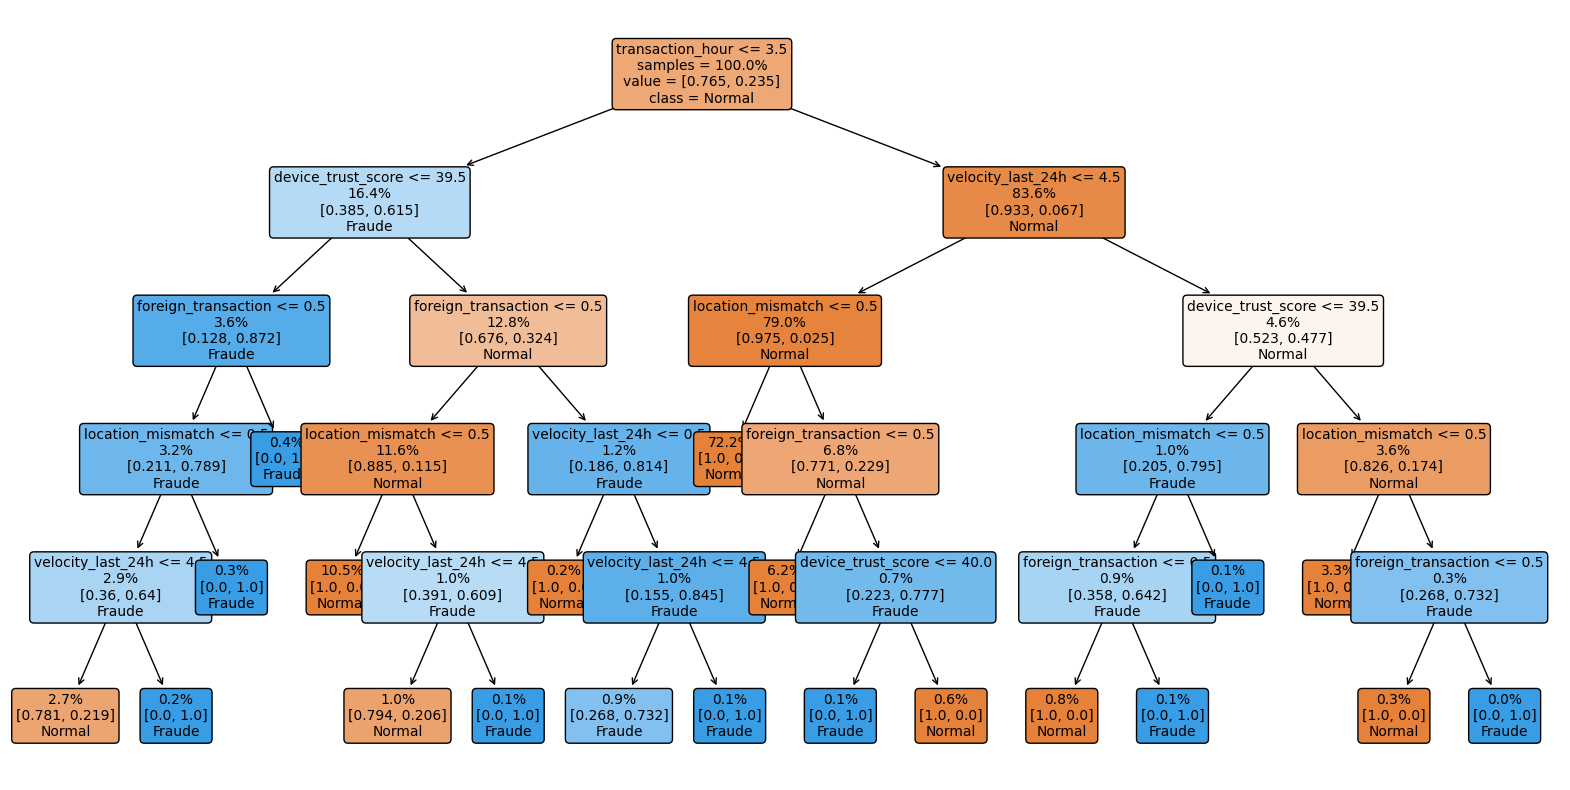

In [22]:
plt.figure(figsize=(20,10))  # ajusta el tamaño para que se vea bien
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=['Normal', 'Fraude'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False,      # quita la medida de impureza (gini)
    proportion=True,     # muestra proporción de clases en lugar de counts
    label='root'
)
plt.show()

In [23]:
# Ver reglas del árbol
tree_rules = export_text(tree, feature_names=list(X_train.columns))
print(tree_rules)

|--- transaction_hour <= 3.50
|   |--- device_trust_score <= 39.50
|   |   |--- foreign_transaction <= 0.50
|   |   |   |--- location_mismatch <= 0.50
|   |   |   |   |--- velocity_last_24h <= 4.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- velocity_last_24h >  4.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- location_mismatch >  0.50
|   |   |   |   |--- class: 1
|   |   |--- foreign_transaction >  0.50
|   |   |   |--- class: 1
|   |--- device_trust_score >  39.50
|   |   |--- foreign_transaction <= 0.50
|   |   |   |--- location_mismatch <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- location_mismatch >  0.50
|   |   |   |   |--- velocity_last_24h <= 4.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- velocity_last_24h >  4.50
|   |   |   |   |   |--- class: 1
|   |   |--- foreign_transaction >  0.50
|   |   |   |--- velocity_last_24h <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- velocity_last_24h >  0.50
|   |   |   |   |--- velocity_last

podemos ver en el arbol que cuando aparece el foreign_transaction > 0.5 casi siempre deriva en fraude.

In [24]:
# Extraer importancia de features
importances = tree.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

                               feature  importance
5                     transaction_hour    0.377235
8                   device_trust_score    0.193262
6                  foreign_transaction    0.181602
9                    velocity_last_24h    0.151623
7                    location_mismatch    0.096277
0   cat__merchant_category_Electronics    0.000000
1          cat__merchant_category_Food    0.000000
2       cat__merchant_category_Grocery    0.000000
4                               amount    0.000000
3        cat__merchant_category_Travel    0.000000
10                      cardholder_age    0.000000


Regresion Logistica

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
logit = LogisticRegression(
    solver='liblinear',
    class_weight={0:1, 1:20},
    max_iter=1000,
    random_state=0
)

logit.fit(X_train, y_train)
y_pred = logit.predict(X_test)

In [27]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1918   52]
 [   3   27]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1970
           1       0.34      0.90      0.50        30

    accuracy                           0.97      2000
   macro avg       0.67      0.94      0.74      2000
weighted avg       0.99      0.97      0.98      2000



SVM

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [34]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(
        class_weight={0:1, 1:20},
        max_iter=10000,
        dual=False,
        random_state=0
    ))
])

svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

In [35]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1919   51]
 [   3   27]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1970
           1       0.35      0.90      0.50        30

    accuracy                           0.97      2000
   macro avg       0.67      0.94      0.74      2000
weighted avg       0.99      0.97      0.98      2000



En este modelo de árbol de decisión, las variables más importantes para detectar fraudes son, por orden de relevancia:

Hora de la transacción (transaction_hour): la mayoría de los fraudes ocurren en ciertas franjas horarias, por lo que esta variable es clave para separar transacciones legítimas de fraudulentas.

Puntuación de confianza del dispositivo (device_trust_score): los dispositivos con baja confianza tienen mayor probabilidad de fraude.

Transacciones extranjeras (foreign_transaction): las transacciones internacionales son más propensas a ser fraudulentas.

Número de transacciones recientes (velocity_last_24h): un alto número de transacciones en poco tiempo indica riesgo.

Desajuste de ubicación (location_mismatch): cuando la ubicación de facturación y la transacción no coinciden, aumenta la probabilidad de fraude.

Por otro lado, variables como monto, edad del titular y categoría del comercio no contribuyen significativamente a la predicción en este dataset, ya que los splits del árbol muestran que no aportan información adicional para distinguir fraudes de transacciones legítimas.

En resumen, el modelo prioriza patrones de comportamiento y riesgo asociado al dispositivo y la transacción por encima de características personales o de monto.